In [62]:
%load_ext autoreload
%autoreload 2

import os
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
import h5py
import logging

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from hydra import compose, initialize
from omegaconf import OmegaConf

#load configs
with initialize(version_base=None, config_path="ltu-cmass/cmass/conf", job_name="test_app"):
    cfg_raw = compose(config_name="config", 
                  overrides=[
                             "nbody=abacuslike", 
                             "nbody.lhid=0",
                             "sim=fastpm", 
                             "survey.geometry=sgc",
                             "bias.hod.seed=1", 
                             "multisnapshot=False", 
                             "nbody.zf=0.500015"                            
                             ])
cfg_raw.meta.cosmofile = '/home/x-csui/workspace/cmass/ltu-cmass/params/latin_hypercube_params.txt'
cfg_raw.meta.wdir = '/home/x-csui/workspace/cmass/cmass_ili_matt'
print(OmegaConf.to_yaml(cfg_raw))

meta:
  wdir: /home/x-csui/workspace/cmass/cmass_ili_matt
  logdir: ${meta.wdir}/logs/
  cosmofile: /home/x-csui/workspace/cmass/ltu-cmass/params/latin_hypercube_params.txt
  fastpm_exec: /home/x-mho1/git/fastpm/src/fastpm
  pinocchio_exec: /home/mattho/git/Pinocchio/src/pinocchio.x
nbody:
  suite: abacuslike
  L: 2000
  'N': 256
  lhid: 0
  matchIC: 0
  supersampling: 3
  save_particles: false
  save_transfer: true
  zi: 10
  zf: 0.500015
  asave:
  - 0.58622
  - 0.60633
  - 0.62644
  - 0.64655
  - 0.66666
  - 0.68677
  - 0.70688
  - 0.72699
  - 0.7471
  - 0.76721
  transfer: CAMB
  order: 2
  B: 2
  N_steps: 32
  COLA: true
  mass_function: Watson_2013
fit:
  path_to_qhalos: quijote/source/Halos/FoF/latin_hypercube_HR
  use_rho_quijote: false
  path_to_qrhos: quijote/source/density_field/latin_hypercube
  Nm: 10
  logMmin: 12.8
  logMmax: 15.8
  verbose: true
  attempts: 10
bias:
  halo:
    model: CHARM
    config_charm: config_v0.yaml
    base_suite: calib_1gpch_z0.5
    L: 1000
  

In [64]:
from cmass.survey.hodlightcone import *

The following cells are largely copied from the `main` function in `cmass.survey.hodlightcone`. The main change is the removal of the final part of the `stitch_lightcone` function to move the fiber-collision step outside. I also used a modified `lightcone.cpp`, allowing `fibercoll` to be called directly and `rdz` to be retrieved from the `lightcone` class at any time.

In [65]:
cfg = OmegaConf.masked_copy(
    cfg_raw, ['meta', 'sim', 'multisnapshot', 'nbody', 'bias', 'survey'])

# Build run config
cfg = parse_nbody_config(cfg)
cfg = parse_hod(cfg)
logging.info('Running with config:\n' + OmegaConf.to_yaml(cfg))
source_path = get_source_path(
    cfg.meta.wdir, cfg.nbody.suite, cfg.sim,
    cfg.nbody.L, cfg.nbody.N, cfg.nbody.lhid
)
# Save with original hod_seed
if cfg.bias.hod.seed == 0:
    hod_seed = cfg.bias.hod.seed
else:
    # (parse_hod modifies it to lhid*1e6 + hod_seed)
    hod_seed = int(cfg.bias.hod.seed - cfg.nbody.lhid * 1e6)
aug_seed = cfg.survey.aug_seed  # for rotating and shuffling

geometry = cfg.survey.geometry  # whether to use NGC, SGC, or MTNG mask
geometry = geometry.lower()

[13:38:30-INFO] Running with config:
meta:
  wdir: /home/x-csui/workspace/cmass/cmass_ili_matt
  logdir: ${meta.wdir}/logs/
  cosmofile: /home/x-csui/workspace/cmass/ltu-cmass/params/latin_hypercube_params.txt
  fastpm_exec: /home/x-mho1/git/fastpm/src/fastpm
  pinocchio_exec: /home/mattho/git/Pinocchio/src/pinocchio.x
nbody:
  suite: abacuslike
  L: 2000
  'N': 256
  lhid: 0
  matchIC: false
  supersampling: 3
  save_particles: false
  save_transfer: true
  zi: 10
  zf: 0.500015
  asave:
  - 0.666660000066666
  transfer: CAMB
  order: 2
  B: 2
  N_steps: 32
  COLA: true
  mass_function: Watson_2013
  ai: 0.09090909090909091
  af: 0.666660000066666
  quijote: false
  cosmo:
  - 0.1755
  - 0.06681
  - 0.7737
  - 0.8849
  - 0.6641
bias:
  halo:
    model: CHARM
    config_charm: config_v0.yaml
    base_suite: calib_1gpch_z0.5
    L: 1000
    'N': 128
    vel: CIC
  hod:
    model: zheng07
    assem_bias: false
    vel_assem_bias: false
    mdef: 200c
    use_conc: true
    default_params

In [ ]:
# survey mask
maskobs = lc.Mask(boss_dir=cfg.survey.boss_dir,
                    veto=True, is_north=False)

In [ ]:
remap_case = 3
zmid = 0.55
nz_dir = os.path.dirname(lc.__file__)

# Setup lightcone constructor
if 'z_range' in cfg.survey:
    zmin, zmax = cfg.survey.z_range
else:
    zmin, zmax = 0.4, 0.7

In [68]:
snap_times = sorted(cfg.nbody.asave)[::-1]  # decreasing order
snap_times = [a for a in snap_times if (zmin < (1/a - 1) < zmax)]
lightcone = lc.Lightcone(
    boss_dir=nz_dir if cfg.survey.fix_nz else None,
    mask=maskobs,
    BoxSize=cfg.nbody.L,
    Omega_m=cfg.nbody.cosmo[0],
    zmin=zmin,
    zmax=zmax,
    zmid=zmid,  # to set the offset of the simulation box
    snap_times=snap_times,
    verbose=True,
    augment=aug_seed,
    remap_case=remap_case,
    seed=42,
    is_north=geometry == 'ngc'
)


In [69]:
# Setup HOD model function
if not cfg.survey.randoms:
    hod_fct = HODEngine(cfg, snap_times, source_path)
else:
    hod_fct = randoms_engine  # for constructing randoms
lightcone.set_hod(hod_fct)

init HOD engine


In [ ]:
#modified stitch_lightcone function
def stitch_lightcone(lightcone, source_path, snap_times, BoxSize, Ngrid,
                     noise_uniform, use_randoms=False):
    # Load snapshots
    for snap_idx, a in enumerate(snap_times):
        logging.info(f'Loading snapshot at a={a:.6f}...')
        if not use_randoms:
            hpos, hvel, _, _ = load_snapshot(source_path, a)
        else:
            nbar_randoms = 3e-5  # number density of CMASS
            Nrandoms = int(nbar_randoms * BoxSize**3)
            hpos = np.random.rand(Nrandoms, 3) * BoxSize
            hvel = np.zeros_like(hpos)

        # Uniformly noise the halos positons in the voxel
        if noise_uniform:
            Delta = BoxSize / Ngrid
            logging.info(
                f'Applying uniform position noise for voxel size {Delta} Mpc/h')
            hpos += np.random.uniform(-Delta/2, Delta/2, size=hpos.shape)
            hpos = np.mod(hpos, BoxSize)  # wrap around the box

        lightcone.add_snap(snap_idx, hpos, hvel)

    return 


In [71]:
logging.info(f'Stitching snapshots a={snap_times}')
stitch_lightcone(
    lightcone, source_path, snap_times,
    cfg.nbody.L, cfg.nbody.N, cfg.bias.hod.noise_uniform,
    use_randoms=cfg.survey.randoms)


[13:39:40-INFO] Stitching snapshots a=[0.666660000066666]
[13:39:40-INFO] Loading snapshot at a=0.666660...


[13:39:41-INFO] Applying uniform position noise for voxel size 7.8125 Mpc/h
[13:39:41-INFO] Populating HOD...
[13:39:41-INFO] Running populate_hod...
[13:39:41-INFO] Using halo-concentration relation...


calling HOD engine


[13:39:42-INFO] Finished populate_hod... (0m0s)


In [ ]:
#get rdz before fiber coll
ra, dec, z,_ = lightcone.get_current_data()  # to initialize the data arrays

In [ ]:
# run fiber collision
lightcone.fibcoll(only_measure=False)

0.15110707776077276

In [ ]:
# get rdz after fiber coll
ra_after_fibcoll, dec_after_fibcoll, z_after_fibcoll, _ = lightcone.get_current_data()

In [75]:
rdz = np.vstack((ra, dec, z)).T
rdz_after_fibcoll = np.vstack((ra_after_fibcoll, dec_after_fibcoll, z_after_fibcoll)).T

In [76]:
rdz.shape, rdz_after_fibcoll.shape

((130027, 3), (110379, 3))

In [5]:
rdz = np.load('/home/x-csui/workspace/cmass/cmass-ili/for_make_plots/rdz_before_fibcoll.npy')
rdz_after_fibcoll = np.load('/home/x-csui/workspace/cmass/cmass-ili/for_make_plots/rdz_after_fibcoll.npy')

In [77]:
def plot_with_rdz_cut(rdz_input, ra_range=None, dec_range=None, z_range=None, s=1, ax = None):

    rdz = rdz_input.copy()
    if ra_range is None:
        ra_range = [0, 360]
    if dec_range is None:
        dec_range = [-90, 90]
    if z_range is None:
        z_range = [0, 1]

    mask = (rdz[:, 0] > ra_range[0]) & (rdz[:, 0] < ra_range[1]) & \
           (rdz[:, 1] > dec_range[0]) & (rdz[:, 1] < dec_range[1]) & \
           (rdz[:, 2] > z_range[0]) & (rdz[:, 2] < z_range[1])

    rdz_cut = rdz[mask]
    # print(rdz_cut)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(rdz_cut[:, 0], rdz_cut[:, 1], s=s,marker='o',facecolors='none', edgecolors='black', alpha=0.6)
    ax.set_xlim(ra_range)
    ax.set_ylim(dec_range)
    return ax

In [78]:
import pymangle
def plot_mask_region(ra_range=None, dec_range=None, show_completeness=False, ax=None):

    mask = pymangle.Mangle('/home/x-csui/workspace/cmass/cmass_ili_matt/obs/mask_DR12v5_CMASS_South.ply')
    resolution = 1000
    show_completeness = False  # Set to False to show coverage map instead

    # Create coordinate grid
    if ra_range[0] > ra_range[1]:  # Handle RA wrap around 0/360
        ra_grid1 = np.linspace(ra_range[0], 360, resolution//2)
        ra_grid2 = np.linspace(0, ra_range[1], resolution//2)
        ra_grid = np.concatenate([ra_grid1, ra_grid2])
    else:
        ra_grid = np.linspace(ra_range[0], ra_range[1], resolution)

    dec_grid = np.linspace(dec_range[0], dec_range[1], resolution)

    # Create meshgrid
    RA, DEC = np.meshgrid(ra_grid, dec_grid)
    ra_flat = RA.flatten()
    dec_flat = DEC.flatten()

    # Get weights from mask
    weights = mask.weight(ra_flat, dec_flat)

    if show_completeness:
        # Show completeness weights
        Z = weights.reshape(RA.shape)
        # Mask out regions with weight = 0
        Z = np.ma.masked_where(Z == 0, Z)
    else:
        # Apply the same mask logic as in your function
        # binary_mask = (weights > np.random.rand(len(ra_flat)))
        binary_mask = (weights > 0)#&(binary_mask)  # Only show regions with completeness > 0.7
        binary_mask = ~binary_mask
        Z = binary_mask.astype(float).reshape(RA.shape)
        Z = np.ma.masked_where(Z == 0, Z)

    # Create the plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))

    if show_completeness:
        im = ax.imshow(Z, extent=[ra_range[0], ra_range[1], dec_range[0], dec_range[1]], 
                        aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, label='Completeness Weight')
    else:
        im = ax.imshow(Z, extent=[ra_range[0], ra_range[1], dec_range[0], dec_range[1]], 
                        aspect='auto', origin='lower', cmap='Blues')

    return ax

/tmp/ipykernel_949918/3447011441.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')


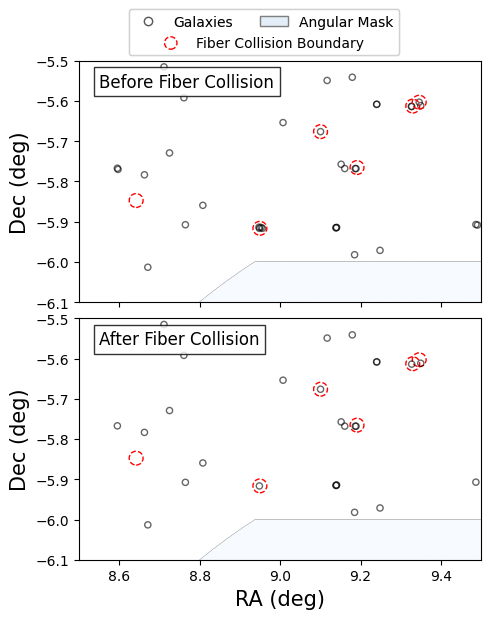

In [83]:
fig,axs = plt.subplots(2, 1, figsize=(5, 6),sharex=True, sharey=True, 
                       gridspec_kw={'hspace': 0})
ra_range = [8.5, 9.5]
dec_range = [-6.1, -5.5]

ax = plot_mask_region(ra_range=ra_range, dec_range=dec_range, show_completeness=False, ax=axs[0])
ax = plot_with_rdz_cut(rdz, ra_range=ra_range, dec_range=dec_range, s=20, ax=ax)
ax.set_aspect('equal', adjustable='box')

from matplotlib.patches import Circle

# mannually set the circle coordinates for fiber collisions
circle_coors = np.array([[8.94963013, -5.91642829],
                        [8.64199102, -5.847464],
                        [9.10045721, -5.67611641],
                        [9.19112236, -5.76537528],
                        [9.32972822, -5.61267269],
                        [9.34570824, -5.60291727]])

for coor in circle_coors:
    circle = Circle(coor, 0.01722, color='red', fill=False, linestyle='--')
    axs[0].add_patch(circle)
    circle2 = Circle(coor, 0.01722, color='red', fill=False, linestyle='--')
    axs[1].add_patch(circle2)

ax = plot_mask_region(ra_range=ra_range, dec_range=dec_range, show_completeness=False, ax=axs[1])
ax = plot_with_rdz_cut(rdz_after_fibcoll, ra_range=ra_range, dec_range=dec_range, s=20, ax=ax)
ax.set_aspect('equal', adjustable='box')

#add legend handels 
from matplotlib.patches import Patch
#legend
#Import cmap 
from matplotlib import cm
from matplotlib.patches import Circle, Patch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle


#for creating legends
cmap = cm.get_cmap('Blues')
color_blue_vmax = cmap(0.1)  # max value in colormap

legend_circle = Circle((0, 0), radius=1, edgecolor='red', facecolor='none', linestyle='--', linewidth=1.5)

legend_elements = [
        Line2D([0], [0], marker='o', markerfacecolor='none', markeredgecolor='black',
           alpha=0.6, linestyle='None', label='Galaxies'),
    plt.scatter([], [], s=80, color='red', marker='o', label='Fiber Collision Boundary',linestyle='--',facecolors='none'),
    Patch(facecolor=color_blue_vmax, edgecolor='gray', label='Angular Mask'),
]

legend_labels = [
        'Galaxies',
        'Angular Mask',
        'Fiber Collision Boundary',
]

first_row_elements = [
        Line2D([0], [0], marker='o', markerfacecolor='none', markeredgecolor='black',alpha=0.6, linestyle='None', label='Galaxies'),
    Rectangle((0, 0), 1, 1, fill=False, edgecolor='none', visible=False),
    Patch(facecolor=color_blue_vmax, edgecolor='gray', label='Angular Mask'),
]
first_row_labels = [
        'Galaxies',
        '',
        'Angular Mask',
]
second_row_elements = [
    plt.scatter([], [], s=80, color='red', marker='o', label='Fiber Collision Boundary',linestyle='--',facecolors='none'),
]

second_row_labels = [
    'Fiber Collision Boundary',
]

# First legend (top row, 2 items)
legend1 = fig.legend(first_row_elements, first_row_labels, 
                     bbox_to_anchor=(0.82, 1.05), ncol=2)

# Second legend (bottom row, 1 item centered)
legend2 = fig.legend(second_row_elements, second_row_labels, 
                     bbox_to_anchor=(0.76, 1.015), ncol=1,frameon=False)

fig.add_artist(legend1)

axs[0].set_ylabel('Dec (deg)',fontsize=15)
axs[1].set_xlabel('RA (deg)',fontsize=15)
axs[1].set_ylabel('Dec (deg)',fontsize=15)

#add text to upper left corner of the first plot
axs[0].text(0.05, 0.95, 'Before Fiber Collision', transform=axs[0].transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
axs[1].text(0.05, 0.95, 'After Fiber Collision', transform=axs[1].transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
plt.tight_layout()